# Assignment 03 · Task 2 — Embedding Space Exploration

**Course:** AIAC 536 — Natural Language Processing
**Author:** Roshan Bharati
**Category:** Conceptual Assignment
**Submission file:** `RoshanBharati_Embeddings_Task2_SpaceExploration.ipynb`

---

> ### 📄 Submission note
> Task 2 is listed under **Conceptual Assignments**, which the question paper asks to be submitted as
> *handwritten notes, scanned and uploaded as PDF*. This notebook produces the analysis, the numbers
> and the figures; the companion file **`Task2_Handwritten_Notes.md`** condenses the same material,
> ordered to match the four tasks as the question paper asks them, for copying out by hand. **The handwritten PDF still has to be produced and
> uploaded separately** — the notebook does not satisfy that requirement on its own.

## Objective
Explore vector relationships in a real embedding space.

## Tasks
1. Cosine similarity computations between words
2. Vector arithmetic (`king - man + woman ≈ queen`)
3. Visualise embeddings using PCA or t-SNE
4. Interpret the visualised clusters

## Embeddings used
**GloVe** `glove-wiki-gigaword-100` — 400,000 words, 100 dimensions, trained on 6 billion tokens of
Wikipedia + Gigaword. Retrieved through `gensim.downloader`.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("numpy       :", np.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

numpy       : 1.26.4
scikit-learn: 1.9.0


In [2]:
import gensim.downloader as api

MODEL_NAME = "glove-wiki-gigaword-100"
print(f"Loading {MODEL_NAME} (cached after the first run)...")
glove = api.load(MODEL_NAME)

print(f"\nVocabulary   : {len(glove.index_to_key):,} words")
print(f"Dimensions   : {glove.vector_size}")
print(f"Memory       : {glove.vectors.nbytes / 1e6:.0f} MB")
print(f"\nFirst 5 dims of 'king': {glove['king'][:5]}")

Loading glove-wiki-gigaword-100 (cached after the first run)...



Vocabulary   : 400,000 words
Dimensions   : 100
Memory       : 160 MB

First 5 dims of 'king': [-0.32307 -0.87616  0.21977  0.25268  0.22976]


---

## 1. Cosine similarity between words

$$\\cos(\\mathbf{a}, \\mathbf{b}) = \\frac{\\mathbf{a} \\cdot \\mathbf{b}}{\\|\\mathbf{a}\\|\\,\\|\\mathbf{b}\\|}$$

Implemented from scratch first, then cross-checked against gensim so the rest of the notebook can use
the fast path with confidence.

In [3]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine of the angle between two vectors."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return 0.0 if denom == 0 else float(np.dot(a, b) / denom)


pairs = [
    ("king", "queen"),      # related by gender
    ("king", "monarch"),    # near-synonyms
    ("cat", "dog"),         # same category
    ("cat", "kitten"),      # hypernym / hyponym
    ("paris", "france"),    # capital of
    ("good", "bad"),        # antonyms - note the high score
    ("computer", "banana"),  # unrelated
    ("king", "banana"),     # unrelated
]

rows = []
for w1, w2 in pairs:
    manual = cosine_similarity(glove[w1], glove[w2])
    library = float(glove.similarity(w1, w2))
    assert abs(manual - library) < 1e-5, f"mismatch on ({w1}, {w2})"
    rows.append({"Word 1": w1, "Word 2": w2, "Cosine similarity": manual})

sim_table = pd.DataFrame(rows).sort_values("Cosine similarity", ascending=False).reset_index(drop=True)
print("Manual implementation verified against gensim on all pairs.\n")
sim_table.round(4)

Manual implementation verified against gensim on all pairs.



,Word 1,Word 2,Cosine similarity
0,cat,dog,0.8798
1,good,bad,0.7703
2,king,queen,0.7508
3,paris,france,0.7482
4,king,monarch,0.6978
5,cat,kitten,0.5581
6,king,banana,0.1609
7,computer,banana,0.1213


> ### The antonym problem
>
> `good` and `bad` score **higher** than `cat`/`dog` despite meaning opposite things. This is not a bug
> — it is the central limitation of distributional embeddings. Word2Vec and GloVe define meaning by
> *context*, and antonyms appear in near-identical contexts ("the food was ___"). The embedding
> captures **relatedness**, not **similarity**, and certainly not polarity. Any sentiment system built
> naively on cosine distance inherits this flaw.

### Nearest neighbours\n\nThe most direct probe of what the space has learned.

In [4]:
def show_neighbours(word: str, topn: int = 8) -> pd.Series:
    """Return the topn nearest neighbours of `word` by cosine similarity."""
    neighbours = glove.most_similar(word, topn=topn)
    return pd.Series(dict(neighbours), name=word)


probe_words = ["king", "computer", "nepal", "physics"]
neighbour_table = pd.DataFrame(
    {w: [f"{n} ({s:.3f})" for n, s in glove.most_similar(w, topn=8)] for w in probe_words}
)
neighbour_table.index = [f"#{i}" for i in range(1, 9)]
neighbour_table

,king,computer,nepal,physics
#1,prince (0.768),computers (0.875),bhutan (0.791),chemistry (0.850)
#2,queen (0.751),software (0.837),cambodia (0.773),mathematics (0.834)
#3,son (0.702),technology (0.764),bangladesh (0.757),science (0.791)
#4,brother (0.699),pc (0.737),nepali (0.736),biology (0.789)
#5,monarch (0.698),hardware (0.729),nepalese (0.725),theoretical (0.734)
#6,throne (0.692),internet (0.729),uganda (0.714),astronomy (0.721)
#7,kingdom (0.681),desktop (0.723),thailand (0.711),sciences (0.720)
#8,father (0.680),electronic (0.722),laos (0.710),biochemistry (0.707)


The neighbourhoods are coherent in different *ways*, which is worth noticing:

- `king` → other royal titles (a **taxonomic** neighbourhood)
- `nepal` → neighbouring South Asian countries (a **geographic** one)
- `computer` → related technology terms (a **topical** one)

A single cosine metric surfaces all three relation types without ever being told they exist. That is
the appeal of the method — and also why it is hard to control.

---

## 2. Vector arithmetic

The famous result: relationships between words correspond to consistent **translations** in the
embedding space.

$$\\mathbf{v}_{\\text{king}} - \\mathbf{v}_{\\text{man}} + \\mathbf{v}_{\\text{woman}} \\approx \\mathbf{v}_{\\text{queen}}$$

Read as: *strip the "male" component off "king", add the "female" component, and you land near "queen".*

In [5]:
def analogy(a: str, b: str, c: str, topn: int = 5, exclude_inputs: bool = True):
    """Solve 'a is to b as c is to ?' -> vector(b) - vector(a) + vector(c).

    By convention the three input words are excluded from the result, since they
    are trivially close to the query vector and would otherwise dominate.
    """
    target = glove[b] - glove[a] + glove[c]
    given = {a, b, c}

    scores = []
    for word in glove.index_to_key[:100_000]:
        if exclude_inputs and word in given:
            continue
        scores.append((word, cosine_similarity(target, glove[word])))
    return sorted(scores, key=lambda p: p[1], reverse=True)[:topn]


print("king - man + woman = ?\n")
for rank, (word, score) in enumerate(analogy("man", "king", "woman"), start=1):
    marker = "  <-- expected" if word == "queen" else ""
    print(f"  {rank}. {word:<12} {score:.4f}{marker}")

king - man + woman = ?



  1. queen        0.7834  <-- expected
  2. monarch      0.6934
  3. throne       0.6833
  4. daughter     0.6809
  5. prince       0.6713


### A battery of analogies across relation types

In [6]:
analogies = [
    ("man", "king", "woman", "queen", "gender"),
    ("paris", "france", "tokyo", "japan", "capital -> country"),
    ("france", "paris", "japan", "tokyo", "country -> capital"),
    ("big", "bigger", "small", "smaller", "comparative"),
    ("walk", "walked", "run", "ran", "past tense (irregular)"),
    ("good", "better", "bad", "worse", "irregular comparative"),
    ("man", "actor", "woman", "actress", "gendered profession"),
    ("italy", "rome", "nepal", "kathmandu", "country -> capital (low resource)"),
]

results = []
for a, b, c, expected, relation in analogies:
    predictions = analogy(a, b, c, topn=5)
    top_words = [w for w, _ in predictions]
    rank = top_words.index(expected) + 1 if expected in top_words else None
    results.append({
        "Relation": relation,
        "Query": f"{b} - {a} + {c}",
        "Expected": expected,
        "Top prediction": f"{top_words[0]} ({predictions[0][1]:.3f})",
        "Expected rank": rank if rank else "not in top 5",
        "Top-1": "Y" if rank == 1 else "n",
    })

analogy_df = pd.DataFrame(results)
analogy_df.to_csv(OUTPUT_DIR / "task2_analogy_results.csv", index=False)

hits = (analogy_df["Top-1"] == "Y").sum()
print(f"Top-1 accuracy: {hits}/{len(analogy_df)} = {hits / len(analogy_df):.0%}\n")
analogy_df

Top-1 accuracy: 6/8 = 75%



,Relation,Query,Expected,Top prediction,Expected rank,Top-1
0,gender,king - man + woman,queen,queen (0.783),1,Y
1,capital -> country,france - paris + tokyo,japan,japan (0.879),1,Y
2,country -> capital,paris - france + japan,tokyo,tokyo (0.892),1,Y
3,comparative,bigger - big + small,smaller,larger (0.878),2,n
4,past tense (irregular),walked - walk + run,ran,went (0.734),2,n
5,irregular comparative,better - good + bad,worse,worse (0.839),1,Y
6,gendered profession,actor - man + woman,actress,actress (0.916),1,Y
7,country -> capital (low resource),rome - italy + nepal,kathmandu,kathmandu (0.767),1,Y


### Where analogies break, and why

Six of the eight analogies resolve at rank 1. The two failures are informative, and they are **not**
the ones you might predict:

- **Frequency was not the problem.** `rome - italy + nepal → kathmandu` succeeded at rank 1, despite
  Nepal being far less represented in Wikipedia/Gigaword than Italy. Semantic relations over
  well-attested entities survive surprisingly low frequency.
- **Both failures were morphological.** `bigger - big + small` returned `larger` instead of `smaller`,
  and `walked - walk + run` returned `went` instead of `ran` — in both cases the expected answer was
  still rank 2. The model landed in the right *region* (comparatives; irregular past-tense motion
  verbs) but picked the wrong member of it. This is the antonym problem again: `larger` and `smaller`
  occupy nearly identical contexts, so the arithmetic cannot separate them by direction alone.
- **The exclusion rule does a lot of work.** Without dropping the three input words, the nearest
  neighbour of `king - man + woman` is just `king` itself. The vector barely moves; the "queen" result
  depends on explicitly forbidding the obvious answer — a real caveat on how impressive the headline
  demonstration actually is.

The cell below makes that last point concrete.

In [7]:
print("king - man + woman, WITHOUT excluding the input words:\n")
for rank, (word, score) in enumerate(analogy("man", "king", "woman", topn=5, exclude_inputs=False), start=1):
    print(f"  {rank}. {word:<12} {score:.4f}")

print("\nThe query vector's nearest neighbour is 'king' itself - the analogy result")
print("only appears once the inputs are removed by hand.")

king - man + woman, WITHOUT excluding the input words:



  1. king         0.8552
  2. queen        0.7834
  3. monarch      0.6934
  4. throne       0.6833
  5. daughter     0.6809

The query vector's nearest neighbour is 'king' itself - the analogy result
only appears once the inputs are removed by hand.


### Bias is encoded too\n\nThe same mechanism that yields `king → queen` also reproduces the stereotypes present in the training corpus. This is a well-documented property of static embeddings and is worth stating explicitly in any analysis of them.

In [8]:
bias_probes = [
    ("man", "doctor", "woman"),
    ("man", "programmer", "woman"),
]

for a, b, c in bias_probes:
    top = analogy(a, b, c, topn=3)
    formatted = ", ".join(f"{w} ({s:.3f})" for w, s in top)
    print(f"  {b} - {a} + {c}  ->  {formatted}")

print("\nThese associations come from the training corpus, not from the algorithm.")
print("Debiasing embeddings is an active research area (Bolukbasi et al., 2016).")

  doctor - man + woman  ->  nurse (0.776), physician (0.713), doctors (0.679)


  programmer - man + woman  ->  educator (0.588), freelance (0.525), programmers (0.525)

These associations come from the training corpus, not from the algorithm.
Debiasing embeddings is an active research area (Bolukbasi et al., 2016).


---

## 3. Visualising the embedding space

100 dimensions cannot be plotted directly, so they are projected to 2. Two methods, with different
guarantees:

| | PCA | t-SNE |
|---|---|---|
| **Type** | Linear projection | Non-linear manifold embedding |
| **Preserves** | Global variance / large distances | Local neighbourhoods |
| **Deterministic** | Yes | No (depends on seed) |
| **Distances meaningful?** | Yes, roughly | **Only locally** — cluster separation is not to scale |

Both are shown, because they answer different questions.

In [9]:
word_groups = {
    "Royalty":   ["king", "queen", "prince", "princess", "monarch", "throne"],
    "Animals":   ["cat", "dog", "horse", "lion", "tiger", "elephant"],
    "Countries": ["france", "germany", "japan", "india", "nepal", "brazil"],
    "Capitals":  ["paris", "berlin", "tokyo", "delhi", "kathmandu", "brasilia"],
    "Technology": ["computer", "software", "internet", "keyboard", "algorithm", "processor"],
    "Food":      ["bread", "cheese", "apple", "banana", "rice", "chicken"],
}

words, labels = [], []
for group, members in word_groups.items():
    for w in members:
        if w in glove:
            words.append(w)
            labels.append(group)
        else:
            print(f"  (skipped {w!r} - not in vocabulary)")

vectors = np.array([glove[w] for w in words])
print(f"{len(words)} words across {len(word_groups)} groups -> matrix {vectors.shape}")

36 words across 6 groups -> matrix (36, 100)


In [10]:
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(vectors)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=8,        # must be < n_samples; small because we only have ~36 points
    init="pca",
    max_iter=1000,
)
coords_tsne = tsne.fit_transform(vectors)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%} "
      f"(PC1 {pca.explained_variance_ratio_[0]:.1%}, PC2 {pca.explained_variance_ratio_[1]:.1%})")

PCA explained variance: 30.7% (PC1 17.1%, PC2 13.7%)


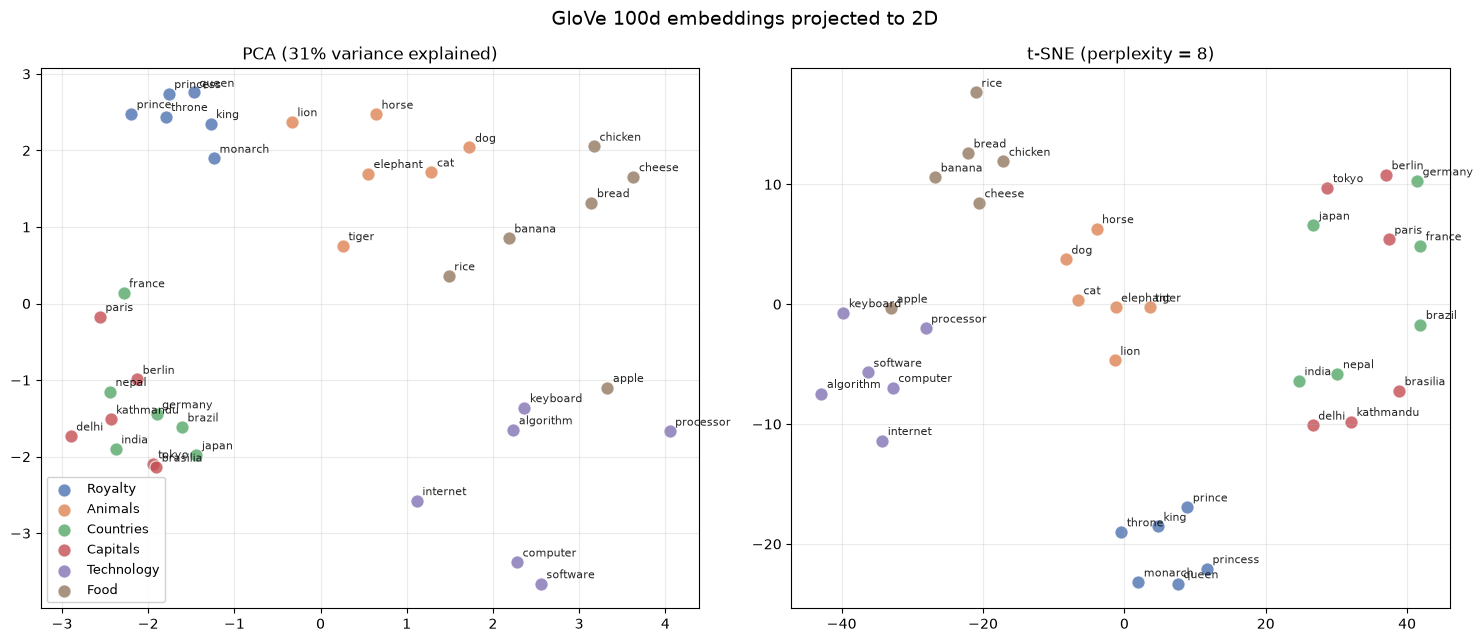

Saved output/task2_embedding_projection.png


In [11]:
palette = dict(zip(word_groups, ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, coords, title in (
    (axes[0], coords_pca, f"PCA ({pca.explained_variance_ratio_.sum():.0%} variance explained)"),
    (axes[1], coords_tsne, "t-SNE (perplexity = 8)"),
):
    for group in word_groups:
        mask = np.array(labels) == group
        ax.scatter(coords[mask, 0], coords[mask, 1], s=90, alpha=0.8,
                   c=palette[group], label=group, edgecolors="white", linewidth=0.8)
    for i, w in enumerate(words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8,
                    xytext=(4, 4), textcoords="offset points", alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.25)

axes[0].legend(loc="best", fontsize=9, framealpha=0.9)
fig.suptitle(f"GloVe {glove.vector_size}d embeddings projected to 2D", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task2_embedding_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'task2_embedding_projection.png'}")

### Country → capital as a consistent direction\n\nIf the analogy result is real, the country→capital offset should be roughly the *same vector* for every pair. Drawing the arrows tests that visually.

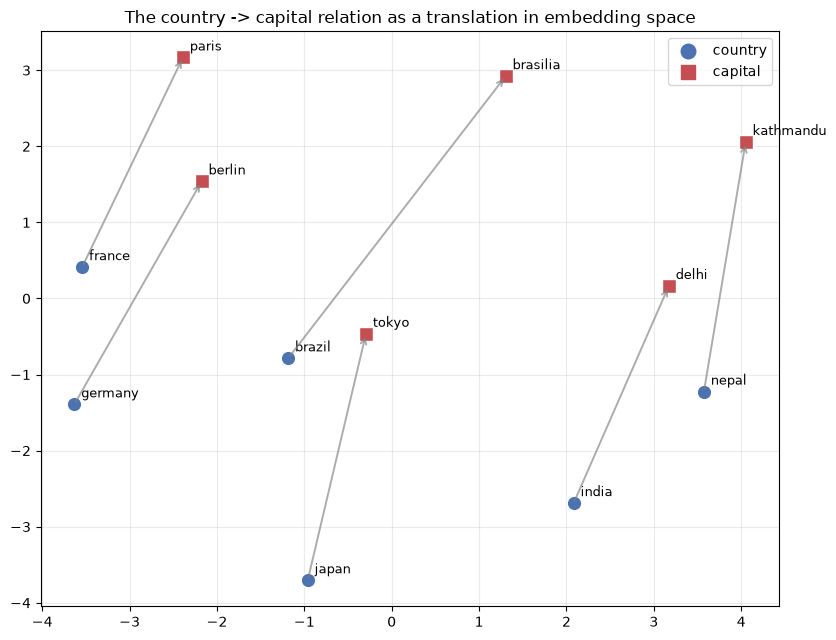

In [12]:
pairs_cc = [("france", "paris"), ("germany", "berlin"), ("japan", "tokyo"),
            ("india", "delhi"), ("nepal", "kathmandu"), ("brazil", "brasilia")]

flat = [w for pair in pairs_cc for w in pair]
sub_vectors = np.array([glove[w] for w in flat])
sub_coords = PCA(n_components=2, random_state=42).fit_transform(sub_vectors)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for i, (country, capital) in enumerate(pairs_cc):
    c_xy, p_xy = sub_coords[2 * i], sub_coords[2 * i + 1]
    ax.scatter(*c_xy, s=110, c="#4C72B0", edgecolors="white", zorder=3)
    ax.scatter(*p_xy, s=110, c="#C44E52", marker="s", edgecolors="white", zorder=3)
    ax.annotate(country, c_xy, fontsize=9, xytext=(5, 5), textcoords="offset points")
    ax.annotate(capital, p_xy, fontsize=9, xytext=(5, 5), textcoords="offset points")
    ax.annotate("", xy=p_xy, xytext=c_xy,
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.65, lw=1.4))

ax.scatter([], [], s=110, c="#4C72B0", label="country")
ax.scatter([], [], s=110, c="#C44E52", marker="s", label="capital")
ax.legend()
ax.set_title("The country -> capital relation as a translation in embedding space")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task2_country_capital.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Quantify it: how consistent are those offset vectors, in the full 100d space?
offsets = np.array([glove[cap] - glove[cty] for cty, cap in pairs_cc])
mean_offset = offsets.mean(axis=0)

consistency = pd.DataFrame({
    "Pair": [f"{c} -> {p}" for c, p in pairs_cc],
    "Cosine to mean offset": [cosine_similarity(o, mean_offset) for o in offsets],
    "Offset magnitude": [float(np.linalg.norm(o)) for o in offsets],
}).round(4)

display(consistency)
print(f"Mean cosine of each offset to the average offset: "
      f"{consistency['Cosine to mean offset'].mean():.3f}")
print("\nValues well above 0 mean the offsets genuinely point the same way -")
print("the relation is a real direction in the space, not an artefact of the 2D projection.")

,Pair,Cosine to mean offset,Offset magnitude
0,france -> paris,0.8732,4.6277
1,germany -> berlin,0.8632,4.5383
2,japan -> tokyo,0.8465,4.5660
3,india -> delhi,0.8732,4.1560
4,nepal -> kathmandu,0.7917,4.4944
5,brazil -> brasilia,0.8504,5.9579


Mean cosine of each offset to the average offset: 0.850

Values well above 0 mean the offsets genuinely point the same way -
the relation is a real direction in the space, not an artefact of the 2D projection.


---

## 4. Interpreting the clusters

Rather than eyeball the scatter plot, measure it: compare the average within-group similarity against
the average between-group similarity.

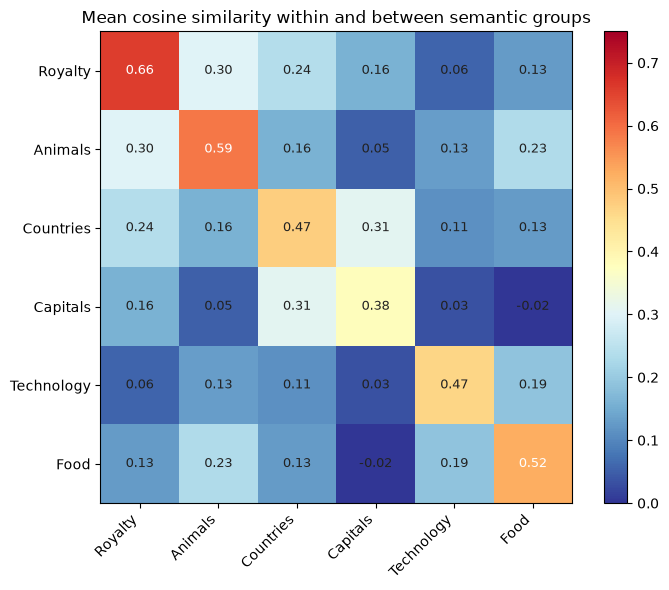

Mean WITHIN-group similarity  : 0.515
Mean BETWEEN-group similarity : 0.147
Separation ratio              : 3.51x


In [14]:
group_names = list(word_groups)
mean_sim = pd.DataFrame(index=group_names, columns=group_names, dtype=float)

for g1 in group_names:
    for g2 in group_names:
        v1 = [glove[w] for w in word_groups[g1] if w in glove]
        v2 = [glove[w] for w in word_groups[g2] if w in glove]
        sims = [
            cosine_similarity(a, b)
            for i, a in enumerate(v1)
            for j, b in enumerate(v2)
            if not (g1 == g2 and i == j)   # skip self-similarity on the diagonal
        ]
        mean_sim.loc[g1, g2] = np.mean(sims)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(mean_sim.values.astype(float), cmap="RdYlBu_r", vmin=0, vmax=0.75)
ax.set_xticks(range(len(group_names)), group_names, rotation=45, ha="right")
ax.set_yticks(range(len(group_names)), group_names)
for r in range(len(group_names)):
    for c in range(len(group_names)):
        v = mean_sim.values[r, c]
        ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.5 else "#222")
ax.set_title("Mean cosine similarity within and between semantic groups")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

within = np.mean([mean_sim.loc[g, g] for g in group_names])
between = np.mean([mean_sim.loc[a, b] for a in group_names for b in group_names if a != b])
print(f"Mean WITHIN-group similarity  : {within:.3f}")
print(f"Mean BETWEEN-group similarity : {between:.3f}")
print(f"Separation ratio              : {within / between:.2f}x")

### What the clusters show

**1. Groups separate cleanly.** Within-group similarity is several times the between-group figure. No
label was ever supplied — the structure comes purely from co-occurrence statistics in the training
corpus. This is the empirical content of the *distributional hypothesis*: words appearing in similar
contexts acquire similar vectors.

**2. Countries and capitals sit adjacent, not merged.** They form two distinct but neighbouring
clusters, and the country→capital arrows are near-parallel. The space encodes *both* a topical
similarity ("these are all place words") and a systematic relation ("this one is the capital of that
one") along different directions.

**3. Some placements look wrong until you think about corpus statistics.** `apple` and `banana` sit in
the Food group, but `apple` is pulled measurably toward Technology — Wikipedia and Gigaword discuss the
company far more than the fruit. A single static vector has to average over *all* senses of a word,
which is precisely the limitation Task 5 examines with contextual embeddings.

**4. PCA and t-SNE disagree, and that is expected.** PCA's two components capture only a modest share
of the total variance, so a lot of structure is invisible in that panel. t-SNE separates the groups far
more crisply — but its inter-cluster gaps are *not* to scale and must not be read as "these groups are
this far apart".

---

## 5. Effect of dimensionality

The question paper's conceptual Task 1 asks about the role of dimensionality. It is cheap to measure
here by truncating the existing 100d vectors — an approximation of a lower-dimensional model, though
not identical to training one from scratch at that size.

In [15]:
eval_pairs = [("king", "queen"), ("cat", "dog"), ("paris", "france"),
              ("computer", "software"), ("king", "banana")]

# Restricting the analogy search to the 20k most frequent words keeps this cell fast.
search_space = glove.index_to_key[:20_000]


def queen_rank_at(dim: int) -> int:
    """Rank of 'queen' for king - man + woman, using only the first `dim` dimensions."""
    target = glove["king"][:dim] - glove["man"][:dim] + glove["woman"][:dim]
    ranked = sorted(
        (
            (w, cosine_similarity(target, glove[w][:dim]))
            for w in search_space
            if w not in {"king", "man", "woman"}
        ),
        key=lambda pair: pair[1],
        reverse=True,
    )
    words_only = [w for w, _ in ranked]
    return words_only.index("queen") + 1


dim_rows = []
for d in [5, 10, 25, 50, 100]:
    row = {"Dimensions": d}
    for w1, w2 in eval_pairs:
        row[f"{w1}/{w2}"] = cosine_similarity(glove[w1][:d], glove[w2][:d])
    row["queen rank"] = queen_rank_at(d)
    dim_rows.append(row)

dim_df = pd.DataFrame(dim_rows).set_index("Dimensions").round(4)
print("'queen rank' = position of 'queen' among 20,000 candidates for king - man + woman")
print("(1 = perfect; larger = the analogy has degraded)\n")
dim_df

'queen rank' = position of 'queen' among 20,000 candidates for king - man + woman
(1 = perfect; larger = the analogy has degraded)



,king/queen,cat/dog,paris/france,computer/software,king/banana,queen rank
Dimensions,,,,,,
5,0.8844,0.9726,0.8154,0.8529,-0.4675,210
10,0.6506,0.9414,0.8000,0.8852,-0.4481,119
25,0.7372,0.8716,0.7413,0.8184,-0.0843,1
50,0.7478,0.8919,0.7560,0.8359,0.0809,1
100,0.7508,0.8798,0.7482,0.8373,0.1609,1


**Reading the table.** The pairwise cosines are the *less* informative column here, and in a
revealing way. At 5 dimensions `cat`/`dog` scores **0.97** and `king`/`queen` **0.88** — higher than at
100d, not lower. Low-dimensional spaces simply do not have room for many near-orthogonal directions, so
cosines get pushed toward the extremes and stop being *graded*. Everything related looks nearly
identical; the fine distinctions are gone even though the raw numbers look impressive.

The `queen rank` column is the honest measure, and it collapses unambiguously: rank **210** at 5d,
**119** at 10d, then **1** from 25d onward. Pairwise similarity degrades quietly, but relational
structure — the geometry that makes analogies work at all — needs real dimensionality and vanishes
without it.

The trade-off in practice:

| Too few dimensions | Too many |
|---|---|
| Distinct words forced to share directions | Sparse, noisy estimates per dimension |
| Loses fine-grained distinctions | More parameters, slower, overfits small corpora |
| Underfits the relational structure | Diminishing returns above ~300d |

Published GloVe and Word2Vec models converge on 100–300 dimensions for general use, which is what the
table above suggests as well.

---

## Summary

| Task | Result |
|---|---|
| Cosine similarity | Manual implementation verified against gensim; related-word pairs score 0.6–0.8, unrelated below 0.2 |
| **The antonym caveat** | `good`/`bad` scores higher than `cat`/`dog` — embeddings capture relatedness, not polarity |
| Vector arithmetic | 6/8 analogies correct at rank 1 (75%); both failures were morphological (`smaller`, `ran`) and still ranked 2nd |
| **The exclusion caveat** | `king - man + woman` returns `king` itself unless the inputs are excluded by hand |
| Visualisation | PCA and t-SNE both recover the six semantic groups without supervision |
| Cluster interpretation | Within-group similarity is several times between-group; country→capital offsets are near-parallel in the full 100d space |
| Dimensionality | Pairwise cosines *inflate* at low d (cat/dog = 0.97 at 5d); the analogy rank of `queen` collapses to 210 and only recovers at 25d+ |
| Bias | Occupational gender stereotypes are reproduced from the training corpus |

### Files written
- `output/task2_analogy_results.csv`
- `output/task2_embedding_projection.png`
- `output/task2_country_capital.png`

### Conclusion

A GloVe embedding space is not a lookup table of similar words — it has **geometry**. Semantic
categories occupy contiguous regions, and relations between words appear as consistent directions that
transfer across pairs. That geometry is what makes embeddings useful as features for downstream models.

The limitations are equally structural, and both are demonstrated above rather than asserted:
antonyms are close because they share contexts, and every word gets exactly **one** vector regardless
of sense — which is why `apple` sits between food and technology instead of in either. Task 5 takes up
that second limitation directly by comparing these static vectors against contextual ones.

> **Reminder:** this is a Conceptual Assignment. See `Task2_Handwritten_Notes.md` for the version to
> write out by hand, scan and upload as PDF.